# Extract dataset
- Load and list down column names.
- Data Cleaning


In [2]:
# importing all necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif



df = pd.read_csv("../datasets/Android_Permission.csv")

# printing all column names
print("Column names:\n", df.columns.to_list())
print("Data shape before cleaning:", df.shape)

print("Total number of NaN values:", df.isna().sum())

#  Drop NaN values
df = df.dropna()
print("Data shape after dropping NaN:", df.shape)
print("Total number of NaN values after dropping NaN:", df.isna().sum().sum())

# data cleaning, keep only numeric features
df = df.select_dtypes(include=[np.number])
df = df.loc[:, (df != 0).any(axis=0)]
print("Data shape after cleaning:", df.shape)

Column names:
 ['App', 'Package', 'Category', 'Description', 'Rating', 'Number of ratings', 'Price', 'Related apps', 'Dangerous permissions count', 'Safe permissions count', 'Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', 'Default : Access all system downloads (S)', 'Default : Access download manager. (S)', 'Default : Advanced download manager functions. (S)', 'Default : Audio File Access (S)', 'Default : Install DRM content. (S)', 'Default : Modify Google service configuration (S)', 'Default : Modify Google settings (S)', 'Default : Move application resources (S)', 'Default : Read Google settings (S)', 'Default : Send download notifications. (S)', 'Default : Voice Search Shortcuts (S)', 'Default : access SurfaceFlinger (S)', 'Default : access checkin properties (S)', 'Default : access the cache filesystem (S)', 'Default : access to passwords for Google accounts (S)', 'Default : act as an account authenticator (S)', 'Default : bind to a wallpaper (S)', 

In [5]:
# BALANCED RANDOM SAMPLING

# Option 1: 5,000 total (2,500 per class)
n_samples = 2500   

df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(n=n_samples, random_state=42))

print("Data shape after balancing:", df.shape)
print("Class distribution after balancing:\n", df['Class'].value_counts(normalize=True) * 100)


Data shape after balancing: (5000, 157)
Class distribution after balancing:
 Class
0    50.0
1    50.0
Name: proportion, dtype: float64


C:\Users\mosqu\AppData\Local\Temp\ipykernel_9912\699504325.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(n=n_samples, random_state=42))


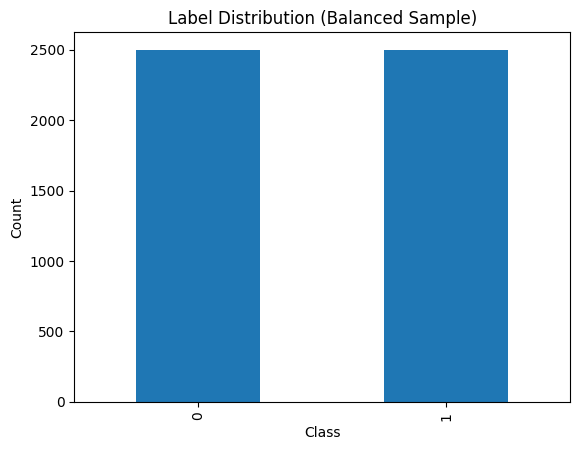

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [6]:
# features and target

X = df.drop('Class', axis=1)
y = df['Class']

# creating a bar chart
y.value_counts().plot(kind='bar')
plt.title("Label Distribution (Balanced Sample)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

label_distribution = y.value_counts(normalize=True) * 100
print(label_distribution)

# Transform

In [7]:
# train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set distribution (%):\n", y_train.value_counts(normalize=True) * 100)
print("Test set distribution (%):\n", y_test.value_counts(normalize=True) * 100)

Train set distribution (%):
 Class
1    50.0
0    50.0
Name: proportion, dtype: float64
Test set distribution (%):
 Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [8]:
# training SVM using pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('svm', SVC(kernel='linear', probability=True, random_state=42))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Predict
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate
print("🔹 SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted', zero_division=0))



🔹 SVM Results
Accuracy: 0.669
Precision: 0.7031494169972352
Recall: 0.669
F1 Score: 0.6544795010308202


In [9]:
# training Boosting using pipeline
boosting_pipeline = Pipeline([
    ('boosting', AdaBoostClassifier(random_state=42))
])

boosting_pipeline.fit(X_train, y_train)
y_pred_boost = boosting_pipeline.predict(X_test)

print("\n🔹 Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print("Precision:", precision_score(y_test, y_pred_boost, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_boost, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_boost, average='weighted', zero_division=0))


🔹 Boosting Results
Accuracy: 0.717
Precision: 0.7407355636318455
Recall: 0.717
F1 Score: 0.7098480444475885


In [10]:
# training Bagging using pipeline
bagging_pipeline = Pipeline([
    ('bagging', BaggingClassifier(random_state=42))
])


bagging_pipeline.fit(X_train, y_train)
y_pred_bag = bagging_pipeline.predict(X_test)

print("\n🔹 Bagging Results")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Precision:", precision_score(y_test, y_pred_bag, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_bag, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_bag, average='weighted', zero_division=0))


🔹 Bagging Results
Accuracy: 0.694
Precision: 0.6962895209726248
Recall: 0.694
F1 Score: 0.6931050944554321


In [ ]:
# training voting using pipeline - hard voting
voting_pipeline_hard = Pipeline([
    ('voting', VotingClassifier(
        estimators=[
            ('svm', SVC(kernel='linear', random_state=42)),  # no probability=True
            ('rf', RandomForestClassifier(
                n_estimators=100, max_depth=10, random_state=42  # optimized RF
            ))
        ],
        voting='hard'
    ))
])

voting_pipeline_hard.fit(X_train, y_train)
y_pred_vote_hard = voting_pipeline_hard.predict(X_test)

print("\n🔹 Voting Results (Hard Voting)")
print("Accuracy:", accuracy_score(y_test, y_pred_vote_hard))
print("Precision:", precision_score(y_test, y_pred_vote_hard, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_vote_hard, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_vote_hard, average='weighted', zero_division=0))

# With Select K Best

